In [1]:
0# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/AI/Coursework/1CWK100/')

In [3]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

In [4]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import requests
import pandas as pd


def get_police_data(poly, months):
    all_rows = []

    for date in months:
        print(f"Fetching {date}...")

        url = f"https://data.police.uk/api/crimes-street/all-crime?poly={poly}&date={date}"
        response = requests.get(url)

        if response.status_code != 200:
            print(f"Failed for {date}")
            continue

        data = response.json()

        for crime in data:
            loc = crime.get("location")

            if loc and loc.get("latitude") and loc.get("longitude"):
                try:
                    all_rows.append({
                        "time": crime["month"],  # YYYY-MM
                        "lat": float(loc["latitude"]),
                        "lon": float(loc["longitude"]),
                        "area": loc["street"]["name"] if loc.get("street") else None,
                        "crime_type": crime["category"]
                    })
                except:
                    continue

    df = pd.DataFrame(all_rows)

    if df.empty:
        print("No data fetched")
        return df

    # Convert time to datetime
    df["time"] = pd.to_datetime(df["time"])

    # OPTIONAL: add random day within month (improves Hawkes model realism)
    df["time"] += pd.to_timedelta(
        np.random.randint(0, 28, size=len(df)),
        unit="D"
    )

    # Sort for model
    df = df.sort_values("time").reset_index(drop=True)

    print(f"Loaded {len(df)} crimes")

    return df



# -----------------------------
# Define region (Manchester example)
# -----------------------------
lat_min, lat_max = 53.3, 53.6
lon_min, lon_max = -2.4, -2.0

grid_size = 3  # increase for more data

lat_ranges = np.linspace(lat_min, lat_max, grid_size)
lon_ranges = np.linspace(lon_min, lon_max, grid_size)

# -----------------------------
# Create polygons
# -----------------------------
months = [
    "2023-10",
    "2023-11",
    "2023-12",
    "2024-01"
]

polys = []

for i in range(len(lat_ranges) - 1):
    for j in range(len(lon_ranges) - 1):
        poly = (
            f"{lat_ranges[i]},{lon_ranges[j]}:"
            f"{lat_ranges[i]},{lon_ranges[j+1]}:"
            f"{lat_ranges[i+1]},{lon_ranges[j+1]}:"
            f"{lat_ranges[i+1]},{lon_ranges[j]}"
        )
        polys.append(poly)

# -----------------------------
# Fetch ALL data
# -----------------------------
all_df = []

for poly in polys:
    df_part = get_police_data(poly, months)

    if not df_part.empty:
        all_df.append(df_part)

# -----------------------------
# Combine
# -----------------------------
df = pd.concat(all_df).drop_duplicates().reset_index(drop=True)

print(df.head())
print("Total rows:", len(df))

print(df.head())

def get_weight(row):
    return row.get("weight", 1.0)

def log_likelihood(params, df):
    mu, alpha, beta, omega = params

    df = df.sort_values("time").reset_index(drop=True)
    logL = 0

    for i in range(len(df)):

        t_i = df.loc[i, "time"]
        lat_i = df.loc[i, "lat"]
        lon_i = df.loc[i, "lon"]

        intensity = mu

        for j in range(i):

            t_j = df.loc[j, "time"]
            dt = (t_i - t_j).total_seconds() / 3600
            d = haversine(lat_i, lon_i, df.loc[j, "lat"], df.loc[j, "lon"]) / 10
            w = get_weight(df.loc[j])
            intensity += alpha * w * np.exp(-omega * dt) * np.exp(-beta * d)
        logL += np.log(intensity + 1e-9)

    T = (df["time"].max() - df["time"].min()).total_seconds() / 3600
    area = (df["lat"].max() - df["lat"].min()) * (df["lon"].max() - df["lon"].min())
    integral = mu * T * area

    return logL - integral

def haversine(lat1, lon1, lat2, lon2):
        R = 6371  # earth

        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c


def spatial_decay(lat1, lon1, lat2, lon2, beta=1):
        dist = haversine(lat1, lon1, lat2, lon2)
        return np.exp(-beta * dist)

def intensity(group, current_time, lat, lon, mu, alpha, beta, omega):

    intensity = mu

    for _, row in group.iterrows():

        dt = (current_time - row["time"]).total_seconds() / 3600

        if dt > 0:

            d = haversine(lat, lon, row["lat"], row["lon"]) / 10

            intensity += alpha * np.exp(-omega * dt) * np.exp(-beta * d)

    return intensity


def fit_mle(df):

    initial = [0.1, 0.5, 1.0, 0.01]

    bounds = [
        (1e-5, 1),
        (1e-5, 5),
        (1e-5, 5),
        (1e-5, 1)
    ]

    result = minimize(
        lambda p: -log_likelihood(p, df),
        initial,
        method="L-BFGS-B",
        bounds=bounds
    )

    return {
        "mu": result.x[0],
        "alpha": result.x[1],
        "beta": result.x[2],
        "omega": result.x[3],
        "success": result.success
    }


def predict_db(collection):
    df = collection.copy()
    df = df.sort_values("time").reset_index(drop=True)
    params = fit_mle(df)

    lat_min, lat_max = 49.8, 58.7
    lon_min, lon_max = -8.2, 2.1

    n_points = 800

    locations = np.column_stack([
        np.random.uniform(lat_min, lat_max, n_points),
        np.random.uniform(lon_min, lon_max, n_points)
    ])

    mu = params["mu"]
    alpha = params["alpha"]
    beta = params["beta"]
    omega = params["omega"]

    print(df.head())

    crime_groups = df.groupby("crime_type")
    current_time = df["time"].max()

    results = []

    for crime_type, group in crime_groups:
        for lat, lon in locations:
            risk = intensity(group, current_time, lat, lon, mu, alpha, beta, omega)

            results.append({
                "crime_type": crime_type,
                "lat": lat,
                "lon": lon,
                "risk": float(risk)
            })

    for crime_type in df["crime_type"].unique():
        values = [r["risk"] for r in results if r["crime_type"] == crime_type]

        min_v = min(values)
        max_v = max(values)

        for r in results:
            if r["crime_type"] == crime_type:
                r["risk_percent"] = ((r["risk"] - min_v) / (max_v - min_v + 1e-9)) * 100

                if r["risk_percent"] > 70:
                    r["level"] = "High"
                elif r["risk_percent"] > 30:
                    r["level"] = "Medium"
                else:
                    r["level"] = "Low"

    #creating the heatmap
    m = folium.Map(location=[53.48, -2.24], zoom_start=6)
    #Setting up layers for each crime type
    for crime_type in df["crime_type"].unique():

        layer = folium.FeatureGroup(
            name=crime_type,
            show=(crime_type == "violent-crime")
        )

        heat_data = []
        #this maps the data taken from previously recorded crimes
        real_points = df[df["crime_type"] == crime_type]
        for _, row in real_points.iterrows():

            heat_data.append([row["lat"], row["lon"], 1])

            folium.CircleMarker(
                location=[row["lat"], row["lon"]],
                radius=6,
                popup=f"""
                Crime: {crime_type}<br>
                Source: Real Data
                """,
                color="blue",
                fill=True,
                fill_opacity=0.6
            ).add_to(layer)

        #this maps predicted crimes
        for r in results:
            if r["crime_type"] == crime_type:

                heat_data.append([r["lat"], r["lon"], r["risk_percent"]])

                folium.CircleMarker(
                    location=[r["lat"], r["lon"]],
                    radius=10,
                    popup=f"""
                    Crime: {r['crime_type']}<br>
                    Risk: {r['risk_percent']:.1f}%<br>
                    Level: {r['level']}
                    """,
                    color=(
                        "red" if r["level"] == "High" else
                        "orange" if r["level"] == "Medium" else
                        "green"
                    ),
                    fill=True,
                    fill_opacity=0.7
                ).add_to(layer)

        #establishing heatmap and adding layers
        HeatMap(
            heat_data,
            radius=100,
            blur=15,
            min_opacity=0.3
        ).add_to(layer)

        layer.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    #saved and opened
    m.save("predicted_crime_heatmap.html")
    return "predicted_crime_heatmap.html"

#predict_db(df)


Fetching 2023-10...
Fetching 2023-11...
Fetching 2023-12...
Fetching 2024-01...
Loaded 1087 crimes
Fetching 2023-10...
Fetching 2023-11...
Fetching 2023-12...
Fetching 2024-01...
Loaded 411 crimes
Fetching 2023-10...
Fetching 2023-11...
Fetching 2023-12...
Fetching 2024-01...
Loaded 113 crimes
Fetching 2023-10...
Fetching 2023-11...
Fetching 2023-12...
Fetching 2024-01...
Loaded 33 crimes
        time        lat       lon                         area     crime_type
0 2023-10-01  53.307814 -2.356160         On or near Hayfields  vehicle-crime
1 2023-10-01  53.335438 -2.231658     On or near Oakdean Court  violent-crime
2 2023-10-01  53.300803 -2.367851   On or near Lilybrook Drive  violent-crime
3 2023-10-01  53.303693 -2.230031  On or near Devonshire Drive    other-crime
4 2023-10-01  53.336645 -2.215897       On or near Village Way   public-order
Total rows: 1624
        time        lat       lon                         area     crime_type
0 2023-10-01  53.307814 -2.356160         On 

In [ ]:
def evaluate_model(df):
    # -----------------------------
    # 1. TIME SPLIT
    # -----------------------------
    split_time = df["time"].quantile(0.8)

    train_df = df[df["time"] <= split_time].reset_index(drop=True)
    test_df  = df[df["time"] > split_time].reset_index(drop=True)

    print(f"Train size: {len(train_df)}")
    print(f"Test size: {len(test_df)}")

    # -----------------------------
    # 2. FIT MODEL
    # -----------------------------
    params = fit_mle(train_df)

    mu = params["mu"]
    alpha = params["alpha"]
    beta = params["beta"]
    omega = params["omega"]

    print("Fitted params:", params)

    # -----------------------------
    # 3. LOG-LIKELIHOOD
    # -----------------------------
    ll = log_likelihood([mu, alpha, beta, omega], test_df)
    print("Test Log-Likelihood:", ll)

    # -----------------------------
    # 4. AUC EVALUATION
    # -----------------------------
    y_true = []
    y_score = []

    # REAL CRIMES
    for _, row in test_df.iterrows():
        score = intensity(train_df, row["time"], row["lat"], row["lon"],
                          mu, alpha, beta, omega)

        y_true.append(1)
        y_score.append(score)

    # FAKE POINTS (no crime)
    lat_min, lat_max = df["lat"].min(), df["lat"].max()
    lon_min, lon_max = df["lon"].min(), df["lon"].max()

    for _ in range(len(test_df)):
        lat = np.random.uniform(lat_min, lat_max)
        lon = np.random.uniform(lon_min, lon_max)

        score = intensity(train_df, split_time, lat, lon,
                          mu, alpha, beta, omega)

        y_true.append(0)
        y_score.append(score)

    auc = roc_auc_score(y_true, y_score)
    print("AUC:", auc)

    # -----------------------------
    # 5. ROC CURVE PLOT
    # -----------------------------
    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1])  # random baseline
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

    # -----------------------------
    # 6. RISK DISTRIBUTION PLOT
    # -----------------------------
    real_scores = y_score[:len(test_df)]
    fake_scores = y_score[len(test_df):]

    plt.figure()
    plt.hist(real_scores, bins=30, alpha=0.7, label="Real crimes")
    plt.hist(fake_scores, bins=30, alpha=0.7, label="Random points")
    plt.legend()
    plt.title("Risk Score Distribution")
    plt.show()

    # -----------------------------
    # 7. HOTSPOT CHECK
    # -----------------------------
    sampled = train_df.sample(n=min(200, len(train_df)), replace=True)

    preds = []

    for _, row in sampled.iterrows():
        lat = row["lat"]
        lon = row["lon"]

        score = intensity(train_df, split_time, lat, lon,
                          mu, alpha, beta, omega)

        preds.append((lat, lon, score))

    preds.sort(key=lambda x: x[2], reverse=True)

    top_k = preds[:50]

    print("Top hotspot sample:")
    for p in top_k[:5]:
        print(p)

    return {
        "log_likelihood": ll,
        "auc": auc,
        "params": params
    }

df = pd.concat(all_df).drop_duplicates().reset_index(drop=True)

# 🔥 SAMPLE HERE
df = df.sample(
    n=min(1000, len(df)),  # cap at 1000
    random_state=42        # reproducible
).sort_values("time").reset_index(drop=True)

print("Sampled size:", len(df))
evaluate_model(df)

Sampled size: 1000
Train size: 802
Test size: 198


# Task 1

## Dataset preparation
Here I imported all the necessary libraries.

In [ ]:
# data preparation steps

# Importing the packages we use
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc

The next thing I did was clean the data. I dropped duplicates of data, and I removed anything that was missing any values. I sorted out a typo that I discovered after printing out all the target features and counting their numbers. Convert the 'Pneumonia' column to numerical using one-hot encoding. I removed the irrelevant feature, which was the patient ID. I found that after plotting a correlation matrix as a heatmap and dropped data entries that had negative values when they should not have. I found them after plotting a boxplot.

In [ ]:
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

#removing duplicates
observations = observations.drop_duplicates()
#removes anything that missing feature values
observations = observations.dropna()

observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')#sorts out error
#Convert 'Pneumonia' column to numerical using one-hot encoding
observations['Pneumonia'] = observations['Pneumonia'].apply(lambda x: 1 if x == 'yes' else 0)

#irrelvant feature
observations = observations.drop(columns='Patient_ID')

#both have negative vaules which they shouldn't
observations = observations[observations['Max_Consolidation_Width'] >= 0]
observations = observations[observations['Max_Consolidation_Height'] >= 0]

The following code prepares the data using a simple 80/20 holdout approach with shuffling for the original training and validation data. Then I do another 60/20 split of the 80% that the models would be tested on first, then the last 20% will be done using a K-fold validation check.

In [ ]:
# Spilting labels and examples
examples = observations.drop(columns='Pneumonia').to_numpy()
labels = observations['Pneumonia'].to_numpy()


# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels
)

Here I scale the data.

In [ ]:
# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data

train_examples = scaler.fit_transform(train_examples)
validate_examples = scaler.transform(validate_examples)
test_examples = scaler.transform(test_examples)

In [ ]:
observation_counts = observations['Pneumonia'].value_counts()
train_unique, train_counts = np.unique(train_labels, return_counts=True)
test_unique, test_counts = np.unique(test_labels, return_counts=True)
# Print ratios (Benign to Malignant)
print(f"The ratio in the observations is: {observation_counts.values[0] / observation_counts.values[1]:.2f}")
print(f"The ratio in the training data is: {train_counts[0] / train_counts[1]:.2f}")
print(f"The ratio in the testing data is: {test_counts[0] / test_counts[1]:.2f}")
print(observations.info())


The ratio in the observations is: 2.48
The ratio in the training data is: 0.40
The ratio in the testing data is: 0.41
<class 'pandas.core.frame.DataFrame'>
Index: 581 entries, 0 to 583
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_Age               581 non-null    int64  
 1   Male                      581 non-null    float64
 2   Xray_Brightness           581 non-null    float64
 3   Xray_Contrast             581 non-null    float64
 4   Silhouette_Sign           581 non-null    int64  
 5   Max_Consolidation_Width   581 non-null    int64  
 6   Max_Consolidation_Height  581 non-null    int64  
 7   Cavity_Presence           581 non-null    float64
 8   Fluid_Level               581 non-null    float64
 9   Air_Bronchograms          581 non-null    float64
 10  Pneumonia                 581 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 54.5 KB
None


## Decision Tree model evaluation
Without any hyperparameters, the initial accuracy was 64.7%. After a decision tree model hyperparameter investigation, which involved raising the minimum sample split and figuring out the model's accuracy when changed. I discovered that the accuracy increased from 64.7% to 67.2% at 45, where it peaked.  



Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.6379310344827587 (or 63.8 %)
Accuracy: 0.6206896551724138 (or 62.1 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.6551724137931034 (or 65.5 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6379310344827587 (or 63.8 %)
Accuracy: 0.6551724137931034 (or 65.5 %)
Accuracy: 0.6551724137931034 (or 65.5 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.646551724137931 (or 64.7 %)


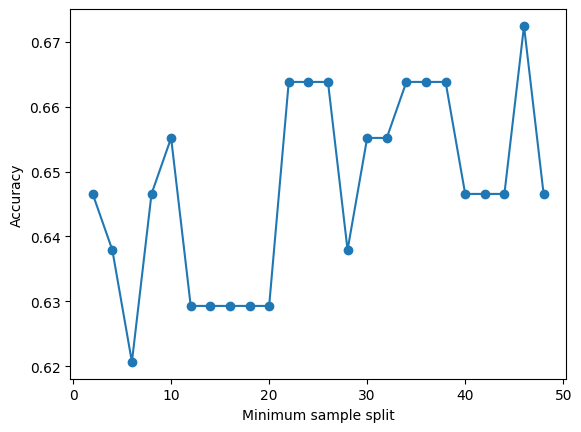

In [ ]:
# Define the range of hyperparameter values we're interested in
min_parent_sizes = list(range(2, 50, 2))
# And a list to hold the resulting accuracies
accuracies = []

# Create a decision tree classifier model object
model = DecisionTreeClassifier(random_state=99)

for min_parent_size in min_parent_sizes:
  # Change the maximum tree depth

  model.set_params(min_samples_split=min_parent_size)
  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

# Show evaluation results graphically
plt.figure()
plt.plot(min_parent_sizes, accuracies, marker='o', linestyle='-')
plt.xlabel('Minimum sample split')
plt.ylabel('Accuracy')
plt.show()

After adjusting my decision tree's hyperparameters, where I discovered that the best accuracy was achieved with a minimum sample split of 45. With that minimum sample split, I performed a K-fold cross-validation. The k-fold cross-validation showed stable accuracy across five folds, with individual accuracies ranging from 60% to 67% and an average accuracy of 62%.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = DecisionTreeClassifier(min_samples_split = 46, random_state=99)
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.62365591 0.64516129 0.60215054 0.60215054 0.67391304]
Average accuracy: 0.629 (or 62.9%)


I ran a final performance test using data that the model had not previously seen, and the result was 29%, which indicates a complete failure to generalize the data.

In [ ]:
pipeline = Pipeline([('model', DecisionTreeClassifier(min_samples_split = 46, random_state=99))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.29


I tested the false positive and true positive rates. The false positive rate (FPR) and true positive rate (TPR) were both 0%; the model predicted every sample as negative. A value of 0.42 was obtained from the ROC AUC tests, meaning a coin toss would accurately predict more cases.

True Positive Rate (TPR): 0.00
False Positive Rate (FPR): 0.00
ROC AUC: 0.42


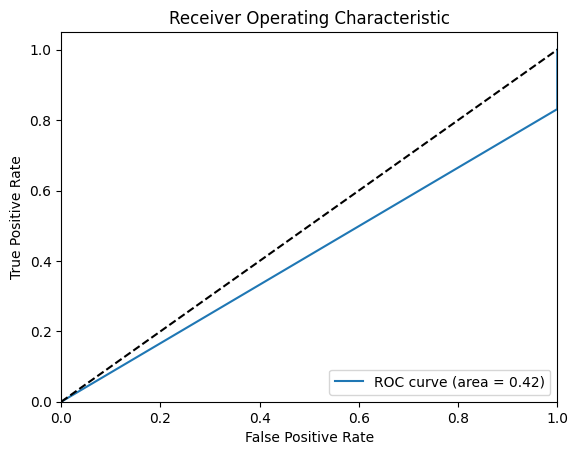

In [ ]:

cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


## k-Nearest Neighbours evaluation
Without any hyperparameters, the initial accuracy was 68.1%.  After conducting a hyperparameter investigation on the k-Nearest Neighbors model, which involved increasing the neighbor count and calculating the model accuracy with these changes, we observed improvements. I discovered that the accuracy increased from 68.1% to 74.1% at 22, where it peaked.



Accuracy: 0.5862068965517241 (or 58.6 %)
Accuracy: 0.6120689655172413 (or 61.2 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155

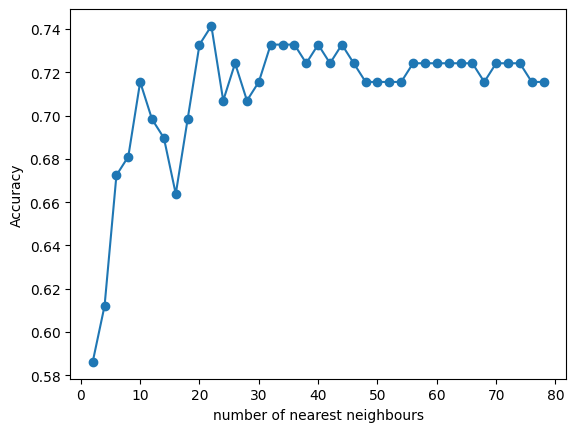

In [ ]:

# Define the range of hyperparameter values we're interested in
neighs = list(range(2, 80, 2))
# And a list to hold the resulting accuracies
accuracies = []

# Create a k-Nearest Neighbours tree classifier model object
model = KNeighborsClassifier()

for neigh in neighs:

  model.set_params(n_neighbors=neigh)
  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

plt.figure()
plt.plot(neighs, accuracies, marker='o', linestyle='-')
plt.xlabel('number of nearest neighbours')
plt.ylabel('Accuracy')
plt.show()

The model performs consistently throughout folds, as evidenced by the consistent accuracy of the k-fold cross-validation across five folds, which ranges from 63 to 73%. The model can guess when a patient has pneumonia with an average accuracy of 68.3%, which is only slightly better than average.



In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = KNeighborsClassifier(n_neighbors = 22)
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.70967742 0.66666667 0.66666667 0.6344086  0.73913043]
Average accuracy: 0.683 (or 68.3%)


I conducted a final performance test using data that the model had not yet seen, and the results showed a performance decrease to 29% meaning it has not generalized the data well.

In [ ]:
pipeline = Pipeline([('model', KNeighborsClassifier(n_neighbors = 22))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predict test data target feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.29


Although I tested the false positive and true positive rates and recorded a value of 0.00 for both, this indicates that the model is predicting all cases as negative, which makes sense sinve there is a class imbalance. The ROC AUC test I performed on it reinforces that idea, as the result was 0.45, which isn't very favorable compared to random guessing which is a 50/50 chance in this case.

True Positive Rate (TPR): 0.00
False Positive Rate (FPR): 0.00
ROC AUC: 0.50


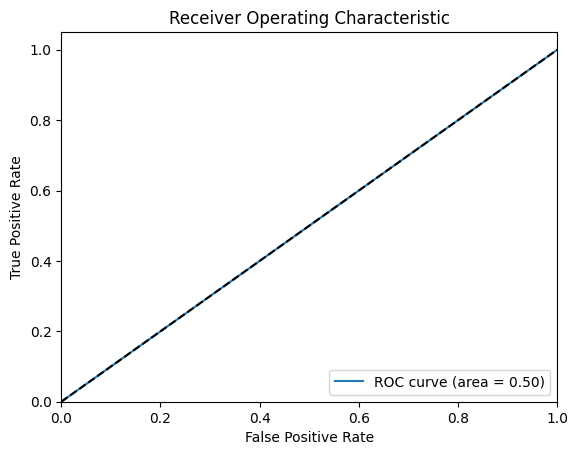

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


## Naive Bayes evaluation
 To determine which Naive Bayes classifier would work best for my data, I looked at all the options.  The BernoulliNB model had a base accuracy score of 34.5%, ComplementNB had a score of 50.9%, and MultinomialNB had a score of 63.8%. I attempted to use a CategoricalNB model, but it failed because the model was meant for categorical data, and my features appeared to be continuous numerical values. Because it performs best with binary/Boolean features, the Gaussian Naive Bayes model was the best, with an accuracy of 71.6%.

 After conducting a hyperparameter investigation on the Gaussian Naive Bayes model, I changed the probabilities of each class and calculated the model accuracy based on these alterations. I found that the accuracy peaked when parent node sizes peaked at [0.5, 0.5] with an accuracy of 53.4%.

Accuracy: 0.5344827586206896 (or 53.4 %)
Accuracy: 0.5172413793103449 (or 51.7 %)
Accuracy: 0.5086206896551724 (or 50.9 %)
Accuracy: 0.5086206896551724 (or 50.9 %)
Accuracy: 0.5086206896551724 (or 50.9 %)


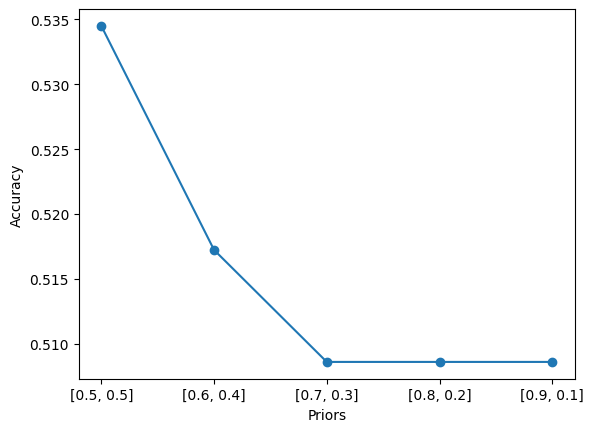

In [ ]:
# And a list to hold the resulting accuracies
accuracies = []

#Prior probabilities of the classes
priors_list = [
    [0.5, 0.5],
    [0.6, 0.4],
    [0.7, 0.3],
    [0.8, 0.2],
    [0.9, 0.1]
]

# Create a Gaussian Naive Bayes classifier model object
model = GaussianNB()

for priors in priors_list:
    model = GaussianNB(priors=priors)
    model.fit(train_examples, train_labels)

    # Use the model to generate predictions for our testing examples
    predictions = model.predict(validate_examples)

    # Calculate the model's accuracy - the fraction of predictions that were correct
    accuracy = accuracy_score(validate_labels, predictions)
    print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

    accuracies.append(accuracy)

plt.figure()
plt.plot([str(p) for p in priors_list], accuracies, marker='o', linestyle='-')
plt.xlabel('Priors')
plt.ylabel('Accuracy')
plt.show()

Then I ran a cross-validation accuracy test on it and got result ranging from 50% to 59% and an average accuracy of 54.5%. The accuracy varies across the folds, and its average accuracy suggests the ability of this model to learn and recognize patterns is restricted.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = GaussianNB(priors=[0.5, 0.5])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.52688172 0.55913978 0.53763441 0.50537634 0.59782609]
Average accuracy: 0.545 (or 54.5%)


I tested this model again with unseen data, and the outcome was 61%. The difference in accuracy suggest that it can genralize the data well more then it seemed.

In [ ]:
pipeline = Pipeline([('model', GaussianNB(priors=[0.5, 0.5]))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.61


I tested the false positive and true positive rates with a 53% false positive rate and the true positive rate being 66%, which tells us the model struggles to tell which cases are actually positive; it just predicts most are. That point is further reinforced by the ROC AUC test I ran, which yielded a 60% result.

True Positive Rate (TPR): 0.66
False Positive Rate (FPR): 0.53
ROC AUC: 0.60


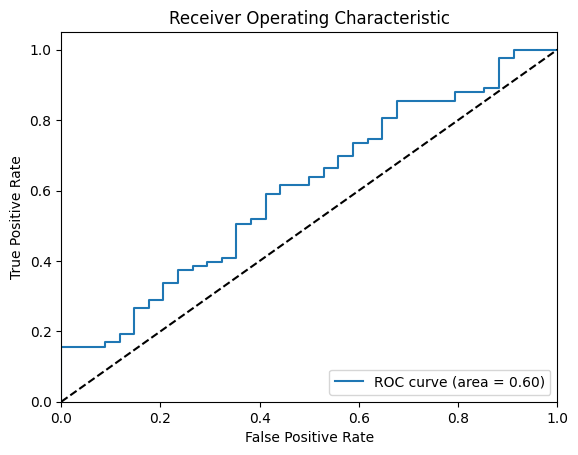

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()



## RandomForestClassifier evaluation

Without any hyperparameters, the initial accuracy was 74.1%. After conducting a hyperparameter investigation on the Random Forest model, which involved increasing the max tree depth, I calculated the model's accuracy with these alterations. I discovered that the accuracy increased from 74.1% to 75% at 18, where it peaked. With that depth of 20, performed many tests initially, like the true and negative posistive rate but I got a result of TPR 0.08 and FPR 0.06 following the patteren of previous model that the dataset is unblanced. I know there was a class_weight parameter, so I added it to see if it would improve the result. It had an opposite effect on the values, but this was not a good thing.






Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)


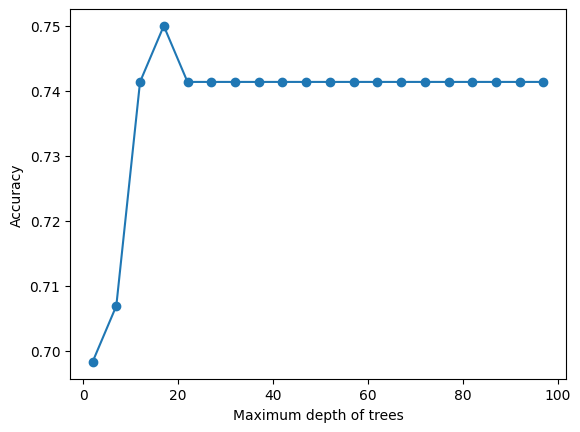

In [ ]:
# Define the range of hyperparameter values we're interested in
depths = list(range(2, 100, 5))
# And a list to hold the resulting accuracies
accuracies = []

# Create a Random Forest classifier model object
model = RandomForestClassifier(random_state=99,class_weight='balanced')

for depth in depths:


  model.set_params(max_depth = depth)
  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

plt.figure()
plt.plot(depths, accuracies, marker='o', linestyle='-')
plt.xlabel('Maximum depth of trees')
plt.ylabel('Accuracy')
plt.show()

The k-fold cross-validation had a stable accuracy across five folds, ranging from 64% to 72%. The flunctionsation demostrate that the model is unstable across the 5 folds. It had an average accuracy of 68.8% overall.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = RandomForestClassifier(max_depth = 18, random_state=99,class_weight='balanced')
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)
# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.72043011 0.69892473 0.64516129 0.65591398 0.7173913 ]
Average accuracy: 0.688 (or 68.8%)


Using data that the model had not previously seen, I ran a final performance test, and the results revealed 71%, a slight 2 %improvement in performance. This tell us the model is good at generalizing the data.

In [ ]:
pipeline = Pipeline([('model', RandomForestClassifier(max_depth = 18, random_state=99,class_weight='balanced'))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.71


But however after testing for the true positive rate (TPR) and false positive rate (FPR), I found that the TPR is 1.0 the model correctly identifies all cases of pneumonia. However, the false positive rate (FPR) was also 1.0 all of the healthy patients, which is a big downside. A value of 0.43 was obtained from the ROC AUC tests, meaning the model is not effective at generalizing data and is just predicting everything to be true rather then negative like it previously did.

True Positive Rate (TPR): 1.00
False Positive Rate (FPR): 1.00
ROC AUC: 0.43


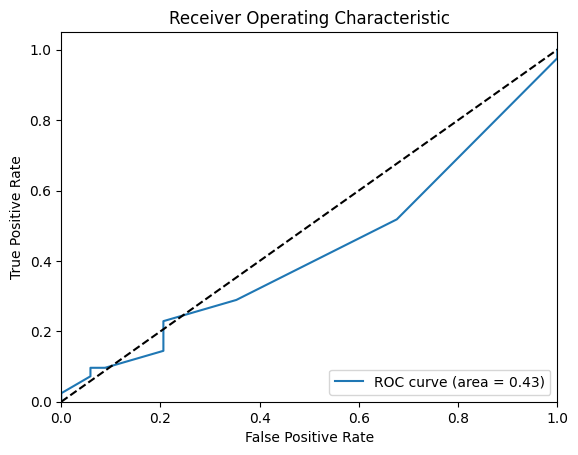

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## Artificial neural network

The initial accuracy was 76.7% in the absence of hyperparameters. I investigated the neural network model's hyperparameters by adding more neurons to the second layer while maintaining the same number of neurons in the first layer, and then I computed the accuracy of the model with these changes. I found that the accuracy peaked at 6 and rose from 76.7% to 77.6%. I discovered that the accuracy peaked at six neurons on the second layer after finishing the test.


Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7758620689655172 (or 77.6 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.71551

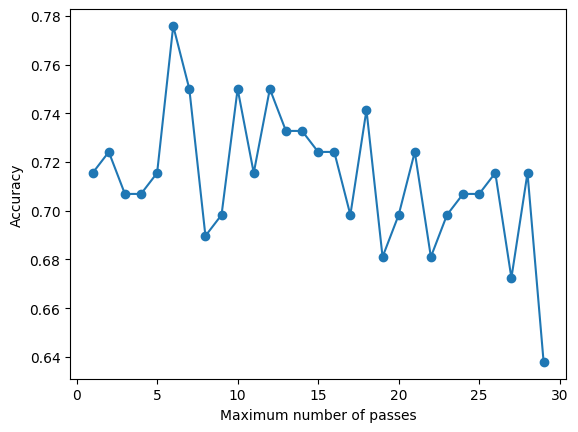

In [ ]:
X = observations.drop(columns=['Pneumonia'])

# Creating a Series for the target feature (diagnosis)
y = observations['Pneumonia']

accuracies = []

pipeline = Pipeline([('mlp', MLPClassifier(max_iter=10000,activation='relu', random_state=99))]) # MLP Classifier

layers = list(range(1, 30, 1))

for layer  in layers :
  # Create a MLP classifier model object
  pipeline.set_params(mlp__hidden_layer_sizes = (5, layer))


  # fit the pipeline on the training data
  pipeline.fit(train_examples, train_labels)

# Making predictions on the test data
  y_pred = pipeline.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score( validate_labels, y_pred)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

plt.figure()
plt.plot(layers , accuracies, marker='o', linestyle='-')
plt.xlabel('Maximum number of passes')
plt.ylabel('Accuracy')
plt.show()

Using that value (5,6), I ran a k-fold cross-validation test, and the average accuracy was 68.3%. The accuracy remained unstable across the five folds, with values ranging from 64% to 72.8%.


In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

pipeline = Pipeline([('mlp', MLPClassifier(hidden_layer_sizes = (5, 6), max_iter=10000,activation='relu', random_state=99))]) ##  MLP Classifier
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.69892473 0.65591398 0.64516129 0.68817204 0.72826087]
Average accuracy: 0.683 (or 68.3%)


I tested the model's final performance with data it had never seen before, and the results indicated a 62% which is a slight drop in performance.

In [ ]:
pipeline = Pipeline([('mlp', MLPClassifier(hidden_layer_sizes = (5, 6), max_iter=10000,activation='relu', random_state=99))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.62


When I checked the true positive and false positive rates, the results showed that the FPR was 82% and the TPR was 88%. This is terrible because the model predicts that the majority of cases will be posistive meaning it can't genralise the data. The fact that the model generalize the data well is further supported by the outcome of my ROC AUC, which came out to be 0.61.

True Positive Rate (TPR): 0.82
False Positive Rate (FPR): 0.88
ROC AUC: 0.61


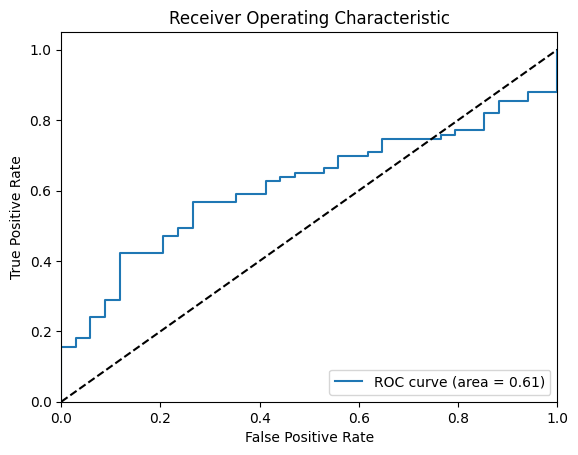

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## LogisticRegression
The initial accuracy was 76.7% in the absence of hyperparameters. I determined the accuracy of the logistic regression model with these modifications after performing a hyperparameter investigation on the model, which involved raising the maximum number of iterations the model can perform. The accuracy remained at 76.7% since the model never peaked and remained at the same value for each iteration.  

Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7672413793103449 (or 76.7 %)


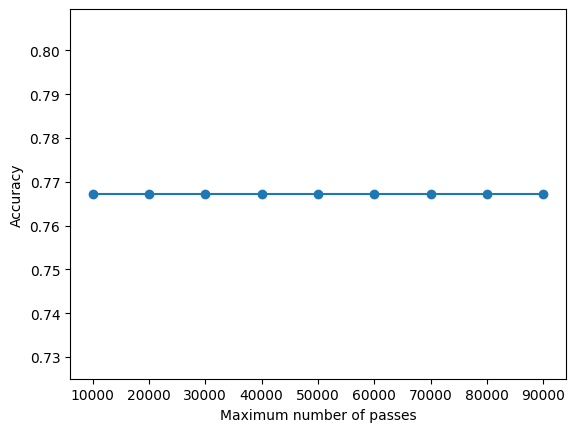

In [ ]:
# Define the range of hyperparameter values we're interested in
passes = list(range(10000, 100000, 10000))
# And a list to hold the resulting accuracies
accuracies = []

# Create a Logistic Regression classifier model object
model = LogisticRegression()

for passe  in passes :


  model.set_params(max_iter = passe)
  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

plt.figure()
plt.plot(passes , accuracies, marker='o', linestyle='-')
plt.xlabel('Maximum number of passes')
plt.ylabel('Accuracy')
plt.show()

I performed a k-fold cross-validation using a value of 10000. The model performs consistently throughout folds, as evidenced by the consistent accuracy of the k-fold cross-validation across five folds, which ranges from 64 to 79%. The model has an average accuracy of 72%, which is a lot better than random guessing.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = LogisticRegression(max_iter = 10000)
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.7311828  0.64516129 0.72043011 0.70967742 0.79347826]
Average accuracy: 0.720 (or 72.0%)


I conducted a final performance test using data that the model had not yet seen, and the results showed a performance fall to 37%, suggesting that the model is overpredicting negatives.

In [ ]:
pipeline = Pipeline([('model', LogisticRegression(max_iter = 10000))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.37


I tested the false positive and true positive rates, recording a false positive rate (FPR) of 0.00% and a true positive rate (TPR) of 0.11%, which indicates that the model mostly ignores the positive class, which makes sense since the data is completely unbalanced with no cases being dominant in the data. The ROC AUC test I did next, where I got 0.59, further reinforces that the model is failing to generalize the data.

True Positive Rate (TPR): 0.11
False Positive Rate (FPR): 0.00
ROC AUC: 0.61


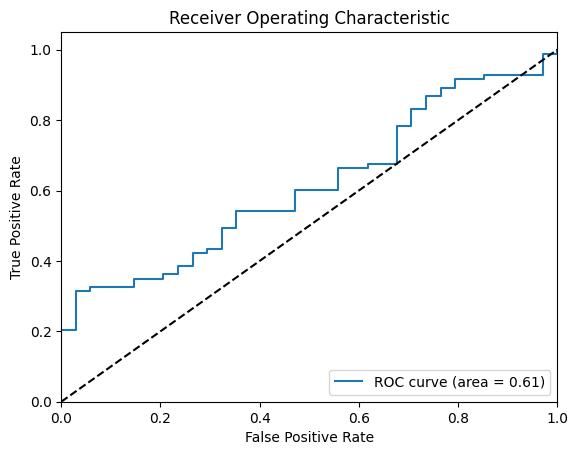

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

##SVC
With no hyperparameters, the accuracy was 71.6% at first. After investigating the logistic regression model's hyperparameters, which included raising the gamma values, I determined the accuracy of the model using these changes. The model's accuracy increased from 71.6% to 72.4% with a gamma value of 10.

Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7241379310344828 (or 72.4 %)


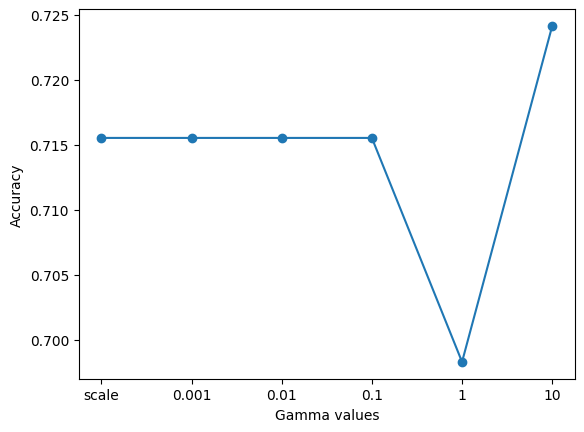

In [ ]:

# And a list to hold the resulting accuracies
accuracies = []
#list of gamma values
gamma_values = ['scale', 0.001, 0.01, 0.1, 1, 10]

# Create a decision tree classifier model object
pipeline = Pipeline([('model', SVC(gamma='scale', probability=True))])

for gamma_value in gamma_values:

  pipeline.set_params(model__gamma=gamma_value)

  # Fit the model to our training data
  pipeline.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions =  pipeline.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

# Show evaluation results graphically
plt.figure()
plt.plot(gamma_values, accuracies, marker='o', linestyle='-')
plt.xlabel('Gamma values')
plt.ylabel('Accuracy')
plt.show()

 I performed a k-fold cross-validation using that value. The model performs consistently throughout folds, as evidenced by the consistent accuracy of the k-fold cross-validation across five folds, which ranges from 71 to 73%. The model can guess when a patient has pneumonia with an average accuracy of 72.2%, which is a little better than average.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

pipeline = Pipeline([('model', SVC(gamma= 10, probability=True))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")


[0.7311828  0.72043011 0.72043011 0.70967742 0.72826087]
Average accuracy: 0.722 (or 72.2%)


I conducted a final performance test using data that the model had not yet seen, and the results showed a performance fall to 71%.

In [ ]:
pipeline = Pipeline([('model', SVC(gamma= 10, probability=True))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.71


 But however, after testing for the true positive rate (TPR) and false positive rate (FPR), I found that the TPR is 1.0; the model correctly identifies all cases of pneumonia. However, the false positive rate (FPR) was also 1.0 for all of the healthy patients, which is a big downside; it's just predicting the majority class. A value of 0.50 was obtained from the ROC AUC tests, meaning the model is just randomly guessing.

True Positive Rate (TPR): 1.00
False Positive Rate (FPR): 1.00
ROC AUC: 0.50


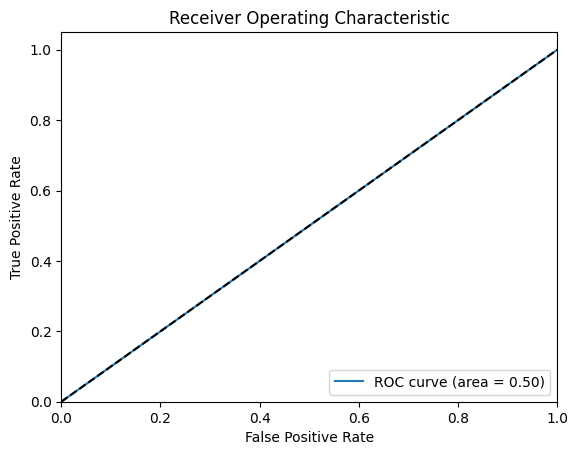

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

##Voting ensemble
For my voting ensemble, I used the three best models: Gaussian Naive Bayes, Random Forest, and MLP Classifier. The first thing I did was calculate the intial model's accuracy, which I got at 68.1% at first.

In [ ]:
# set the details of the classifiers we want to use (all using their default hyperparameters)
model1 = GaussianNB(priors=[0.5, 0.5])
model2 = RandomForestClassifier(max_depth = 17, random_state=99,class_weight='balanced')
model3 =  MLPClassifier(hidden_layer_sizes = (5, 6), max_iter=10000,activation='relu', random_state=99)  # step 2: MLP Classifier


# Create a hard-voting ensemble composed of a k-NN, NB and DT classifier
model = VotingClassifier(estimators=[('gb', model1), ('rf', model2), ('mlp', model3)], voting='soft')

# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(validate_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.6810344827586207 (or 68.1 %)


Then I did a cross-validation test on it across 5 receiving accuracies from 59% to 73%, averaging to 66.2%.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = VotingClassifier(estimators=[('gb', model1), ('rf', model2), ('mlp', model3)], voting='soft')
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")



[0.67741935 0.6344086  0.66666667 0.59139785 0.73913043]
Average accuracy: 0.662 (or 66.2%)


But that accuracy drops to 65% after retesting the model accuracy on data it hasn't seen. It didn't change, meaning it generalized the data well to an extent.

In [ ]:
pipeline = Pipeline([('model', VotingClassifier(estimators=[('gb', model1), ('rf', model2), ('mlp', model3)], voting='soft'))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.65


Again, class imbalance was observed in the true positive and false positive rates, where 72% of positive cases were correctly identified, while 62% of healthy patients were misdiagnosed as positive. And with an ROC AUC of 0.59, the voting class model doesn't generalize data very well.

True Positive Rate (TPR): 0.76
False Positive Rate (FPR): 0.62
ROC AUC: 0.59


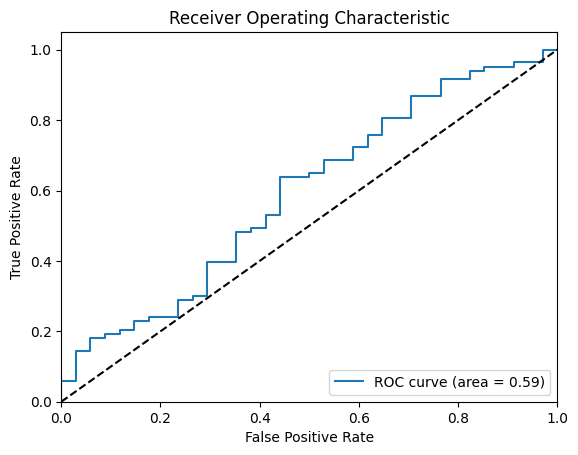

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## Bagging ensemble

With my GaussianNB model, I applied a bagging classifier.Increasing the number of base models the ensemble will utilize is the result of a hyperparameter inquiry into the bagging ensemble model. After using and comparing those three values, I discovered that 3 produced the best results: 2, 3, and 4.

Accuracy: 0.5517241379310345 (or 55.2 %)
Accuracy: 0.5517241379310345 (or 55.2 %)
Accuracy: 0.5517241379310345 (or 55.2 %)
Accuracy: 0.5431034482758621 (or 54.3 %)
Accuracy: 0.5431034482758621 (or 54.3 %)
Accuracy: 0.5258620689655172 (or 52.6 %)
Accuracy: 0.5344827586206896 (or 53.4 %)
Accuracy: 0.5258620689655172 (or 52.6 %)


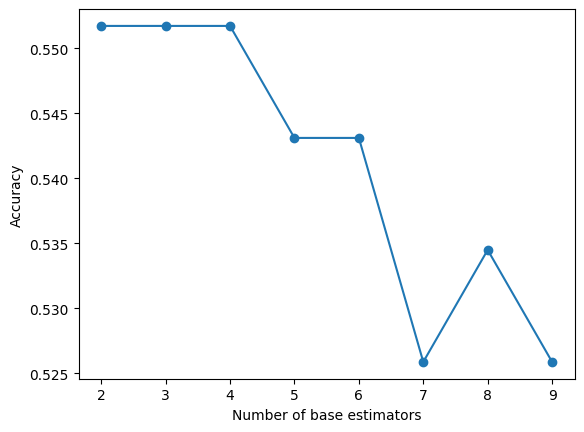

In [ ]:
# Define the range of hyperparameter values we're interested in
model_copies = list(range(2, 10, 1))
# And a list to hold the resulting accuracies
accuracies = []

# Create a Bagging classifier model object
model = BaggingClassifier(estimator = GaussianNB(priors=[0.5, 0.5]), random_state=0)

for model_copy in model_copies:

  # Change the number of base estimators
  model.set_params(n_estimators=model_copy)

  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(accuracy)

# Show evaluation results graphically
plt.figure()
plt.plot(model_copies, accuracies, marker='o', linestyle='-')
plt.xlabel('Number of base estimators')
plt.ylabel('Accuracy')
plt.show()








I run a k-fold cross-validation over five folds and obtain an average accuracy 54 and accuracies ranging from 51 to 61%. This indicates that while adding more base models does enhance the data, it's not very reliable.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = BaggingClassifier(estimator=GaussianNB(priors=[0.5, 0.5]),n_estimators=3, random_state=0)
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")


[0.51612903 0.5483871  0.52688172 0.51612903 0.60869565]
Average accuracy: 0.543 (or 54.3%)


Using data that the model had never seen before, I conducted a final performance test, and the outcome was 67%, which is reasonably decent. It indicates that it was able to somewhat generalize the facts.

In [ ]:
pipeline = Pipeline([('model',BaggingClassifier(estimator=GaussianNB(priors=[0.5, 0.5]),n_estimators=3, random_state=0))])
pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.67


My True Positive Rate (TPR) and False Positive Rate (FPR) results were 0.83 and 0.74, respectively, which further suggests that there may be some problems with class balancing. The ROC AUC, the last test, received a score of 0.60, further suggesting that the data isn't generalized well.

True Positive Rate (TPR): 0.83
False Positive Rate (FPR): 0.74
ROC AUC: 0.60


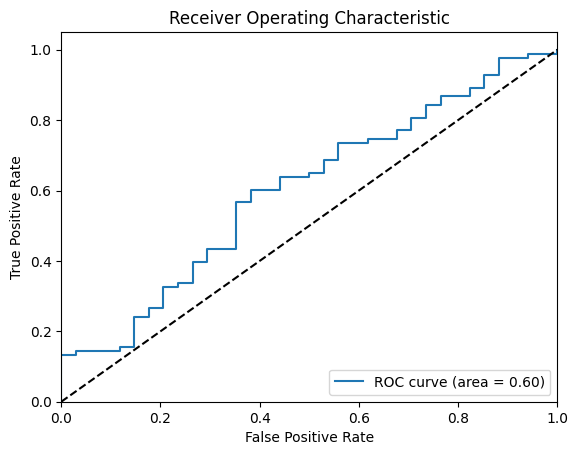

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

##Stacking ensemble

I utilized the top three models for my stacking ensemble: MLP Classifier, Random Forest, and Gaussian Naive Bayes. I started by calculating the intail model's accuracy, which I initially found to be 71.6%.

In [ ]:
# set the details of the classifiers we want to use
model = StackingClassifier(
    estimators=[
        ('gb', GaussianNB(priors=[0.5, 0.5])),
        ('rf', RandomForestClassifier(max_depth = 17, random_state=99,class_weight='balanced')),
        ('mlp', MLPClassifier(hidden_layer_sizes = (5, 6), max_iter=10000,activation='relu', random_state=99))
    ],
    final_estimator=LogisticRegression()
)

# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(validate_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7155172413793104 (or 71.6 %)


After that, I ran a cross-validation test across five folds, and the results ranged from 68% to 72%, with an average of 70.3%.

In [ ]:
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

model = StackingClassifier(
    estimators=[
        ('gb', GaussianNB(priors=[0.5, 0.5])),
        ('rf', RandomForestClassifier(max_depth = 17, random_state=99,class_weight='balanced')),
        ('mlp', MLPClassifier(hidden_layer_sizes = (5, 6), max_iter=10000,activation='relu', random_state=99))
    ],
    final_estimator=LogisticRegression()
)

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")


[0.69892473 0.69892473 0.67741935 0.72043011 0.7173913 ]
Average accuracy: 0.703 (or 70.3%)


However, after retesting the accuracy on data it hasn't seen, that accuracy increases to 71%, proving that the model has indeed generalized the data.

In [ ]:
pipeline = Pipeline([('model', StackingClassifier(
    estimators=[
        ('gb', GaussianNB(priors=[0.5, 0.5])),
        ('rf', RandomForestClassifier(max_depth = 17, random_state=99,class_weight='balanced')),
        ('mlp', MLPClassifier(hidden_layer_sizes = (5, 6), max_iter=10000,activation='relu', random_state=99))
    ],
    final_estimator=LogisticRegression()
))])

pipeline.fit(non_test_examples, non_test_labels)
accuracy = pipeline.score(test_examples, test_labels)
y_pred = pipeline.predict(test_examples)#predct test data targert feature results
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.71


 Unfortunately, there is a contrasting story shown by the True Positive Rate (TPR) and False Positive Rate (FPR). After completing the test, I received 1.00 for TPR and 1.00 for FPR, indicating that the model predicts positive results for all but 1% of cases.  With a final test ROC AUC of 60%, the model appears to be completely almost incapable of generalizing data.

True Positive Rate (TPR): 1.00
False Positive Rate (FPR): 1.00
ROC AUC: 0.60


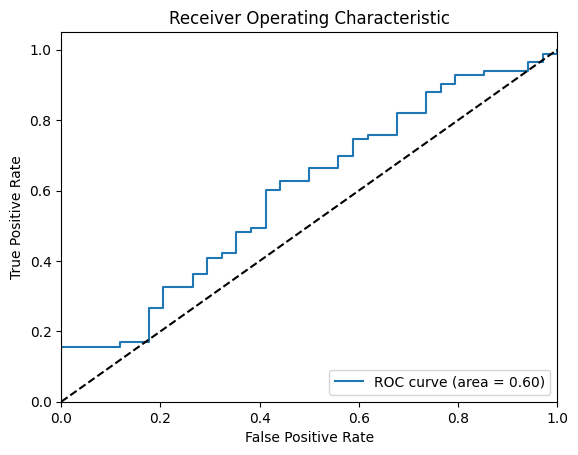

In [ ]:
cm = confusion_matrix(test_labels ,y_pred) #actul answer compared  with predicted answers
# let us define first
TP = cm[1, 1]    # True Positives
FN = cm[1, 0]     # False Negatives
FP = cm[0, 1]     # False Positives
TN = cm[0, 0]      # True Negatives


# calculate TPR and FPR
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)


print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

y_prob = pipeline.predict_proba(test_examples)[:, 1]


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Task 2



> Colleague's claim: "*Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides*"



##Introduction
I explain why I somewhat agree with my colleagues's statement in the following part of the document. When they claim that there are no drawbacks to using raw image data, I do think they are incorrect. I'll evaluate every aspect of his claim critically and support my findings with my own research and code-based investigations.

## Dataset and model preparation


I imported the dataset from https://huggingface.co/datasets/hf-vision/chest-xray-pneumonia here, transformed all the images to consistent size. I used a Convolutional neural network (CNN) since they are considered the best to use when using image data. I used a tutorial from this website to help me get started https://www.datacamp.com/tutorial/pytorch-cnn-tutorial.

In [ ]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
print(torch.__version__)  # This should print the installed PyTorch version
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader

# we load pneumonia dataset from hf-vision/chest-xray-pneumonia
dataset = load_dataset("hf-vision/chest-xray-pneumonia")

# lets define the Transform
# transforms.ToTensor() does exactly this: (H, W, C) -> (C, H, W) and [0, 255] -> [0.0, 1.0]
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize all images to a consistent size
    transforms.Grayscale(num_output_channels=3), # Convert all images to 3 channels
    transforms.ToTensor()
])

# Apply transform efficiently
def apply_transform(batch):
    # Apply the transform to the 'image' column and rename it to 'inputs'
    batch['inputs'] = [transform(image) for image in batch['image']]
    batch['labels'] = batch['label'] # Rename 'label' to 'labels' to match your code style
    return batch

# Apply transformations on the fly
encoded_dataset = dataset.with_transform(apply_transform)

# lets check the samples
print(f"Training data samples: {len(encoded_dataset['train'])} samples")
print(f"Test data samples: {len(encoded_dataset['test'])} samples")
print(f"validation samples: {len(encoded_dataset['validation'])} samples")
print(f"Single Input samples (Channels, Height, Width): {encoded_dataset['train'][0]['inputs'].shape}")

2.9.0+cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/78.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

Training data samples: 5216 samples
Test data samples: 624 samples
validation samples: 16 samples
Single Input samples (Channels, Height, Width): torch.Size([3, 224, 224])


I was checking the dataset feature labels.

In [ ]:
print(dataset['train'].features['label'].names)

['NORMAL', 'PNEUMONIA']


The data was already pre-split, but here I separated them into batches.

In [ ]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
# this is the custom collate function to handle the dictionary format from the dataset
def collate_fn(batch):
    # batch is a list of dictionaries with 'inputs' and 'labels' keys
    inputs = torch.stack([item['inputs'] for item in batch])
    labels = torch.tensor([item['labels'] for item in batch])
    return {'inputs': inputs, 'labels': labels}

# Create DataLoaders with custom collate function for training and testing
train_loader = DataLoader(
    encoded_dataset['train'],
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    encoded_dataset['test'],
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)


# DataLoader for the separate validation data from the dataset (for post-training validation/analysis)
eval_validation_loader = DataLoader(
    encoded_dataset['validation'],
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

print("DataLoaders created successfully: train_loader, val_loader (for during training), test_loader (original test set), and eval_validation_loader (dataset's validation split for post-training check).")

DataLoaders created successfully: train_loader, val_loader (for during training), test_loader (original test set), and eval_validation_loader (dataset's validation split for post-training check).


I'm just testing if everything is okay by previewing the images.

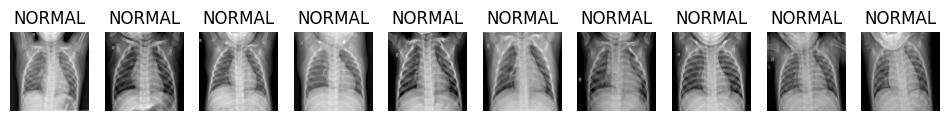

In [ ]:
# this is a function to plot images in a grid
def plot_images(images, labels, class_names):
    fig, axes = plt.subplots(1, 10, figsize=(12, 3))
    for i in range(10):
        # If image is a tensor, convert to numpy and transpose
        if hasattr(images[i], 'numpy'):
            img = images[i].numpy().transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
        else:
            img = images[i]
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis('off')
    plt.show()

# Define CIFAR-10 class names
class_names = ['NORMAL', 'PNEUMONIA']

# Get first 10 images from the encoded_dataset
images = [encoded_dataset['train'][i]['inputs'] for i in range(10)]
labels = [encoded_dataset['train'][i]['labels'] for i in range(10)]

# Plot first 10 images from the training data
plot_images(images, labels, class_names)

Here I set up my CNN model that I'll be using to run all my investigations.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        #simlar to week 9 nn model
        # First convolutional layer / hidden layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional layer / hidden layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional layer / hidden layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc_bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        # First Feature extraction block
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        # Second Feature extraction block
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        # Third Feature extraction block
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        #Layers expect 2D input
        x = x.view(-1, 128 * 28 * 28)

        # Fully connected layers
        x = F.relu(self.fc_bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x


model = CNN()#Instantiating a model
print(model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc_bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out

Here I defined the loss function that measures the accuracy of the model's predictions.

In [ ]:
# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer configured successfully.")

Loss function and optimizer configured successfully.


Here the model is trained.

In [ ]:
# 3. Set up the timer
start_time = time.time()

# number of epochs to train
num_epochs = 5  # Starting with 5 epochs for demonstration

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, batch in enumerate(train_loader):
        # Extract inputs and labels from batch dictionary
        inputs = batch['inputs']
        labels = batch['labels']

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)

        # make sure labels are of type Long (always optional, we have taken this just for on safer side)
        labels = labels.long()

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Perform a single optimization step (parameter update)
        optimizer.step()

        # Accumulate the loss
        running_loss += loss.item()

        # Print statistics every 100 batches
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}')
            running_loss = 0.0

print('Finished training')

# 4. Calculate total time
end_time = time.time()
elapsed_time = end_time - start_time
print('Finished training')
print(f"Total training time on: {elapsed_time:.2f} seconds")

Finished training
Finished training
Total training time on: 3676.56 seconds


## Section 1: Performance
Analysing my colleague's claim about improved performance using raw x-ray image data.

My colleague's claim about improved performance using raw x-ray image data directly is largely correct. By directly giving models raw x-ray image data, they will gain access to a lot more data than information derived from manual measurements. (Kumar et al., 2025) directly support this claim when stating, "Conventional medical image analysis techniques are constrained by manual effort… and less sophisticated feature extraction, whereas deep learning methods offer automated, consistent, and adaptable capabilities." This source supports the idea that using manual measurements limits the potential of models, while raw images allow deep learning models to extract richer features that we've missed or not thought of to measure. Deep learning using medical images offers a high potential for increased accuracy due to the deep learning model's interpretation of significant features, according to a study by (Olamilekan Shobayo and Reza Saatchi, 2025).  The models can identify features that may be overlooked by humans, as the manual measurements used in these models rely entirely on human judgment. We decide which values hold significance and warrant inclusion. Unfortunately, these processes can introduce inconsistency, errors, and biased results; it's even possible for subtle abnormalities to be missed. In contrast, using raw images likely yields more accurate results, as the deep learning model will make more automated decisions about which features are important, potentially detecting patterns and features we may overlook.

Although x-ray images can actually make the performance of models worse, especially with low-quality raw x-ray images, they may have labeling errors, which can also introduce significant biases (Varoquaux and Cheplygina, 2022). Biases involved in a model's performance are a huge issue. Paired with the fact that raw x-ray images vary due to different hospitals having different resources, the quality of x-ray images could be different from what the model was trained on, and as a result of these factors, the model will likely misdiagnose a lot of patients and struggle with generalizability with other datasets, resulting in poor performance compared to using manual measurements. However, these problems can be fixed; models should use high-quality image sets from sources confirmed to be accurate. They may be expensive and hard to get, but necessary for a great model.

###Investigations: Performance / Accuracy testing
I do an accuracy / performance check here without any parameters.

In [ ]:
model.eval() # Set the model to evaluation mode
correct_predictions = 0
total_samples = 0

with torch.no_grad(): # Disable gradient calculation for evaluation
    for batch in test_loader:
        inputs = batch['inputs']
        labels = batch['labels']

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability

        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

accuracy = (correct_predictions / total_samples) * 100
print(f'Accuracy of the model on the test images: {accuracy:.2f}%')#the accuracy indicates how well the model is performing on the test dataset.

Accuracy of the model on the test images: 84.46%


As you can see, my CNN model performed a lot better compared to my best model, the task 1 model, which used a numerical dataset. Without any parameter, the Gaussian Naive had 71.6% accuracy compared to my model now, which is 80.13%. The accuracy may change for you when you are running it because I set the training data to shuffle randomly, but even when shuffled, the accuracy still stays high which supports the claim.

Screenshot of my test.

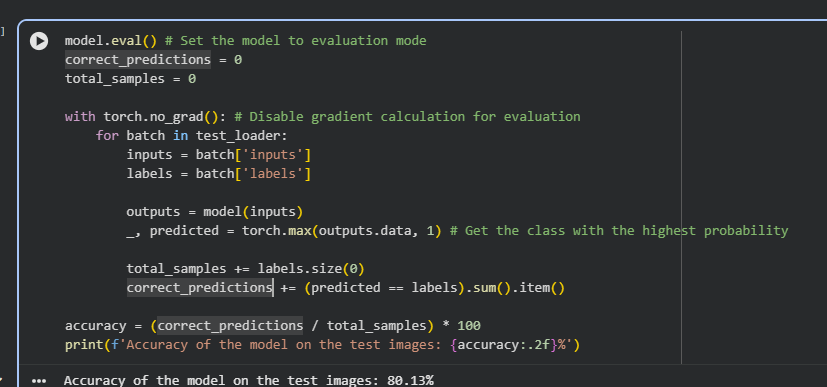

In [ ]:
#Ecprimenting with learning rates
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
validation_accuracies_lr = []


for lr in learning_rates:
    print(f"\nTraining with Learning Rate: {lr}")

    # 1. Re-initialize the model for a fresh start
    # 2. Define the optimizer with the CURRENT learning rate
    current_model = CNN()
    optimizer = optim.Adam(current_model.parameters(), lr=lr)

    num_epochs_explore = 3

    # 3. Training Loop
    for epoch in range(num_epochs_explore):
        current_model.train()
        running_loss = 0.0
         # Extract inputs and labels from batch dictionary
        for i, batch in enumerate(train_loader):
            inputs = batch['inputs']
            labels = batch['labels']
            optimizer.zero_grad()# Zero the parameter gradients
            outputs = current_model(inputs)# Forward pass: compute predicted outputs by passing inputs to the model
            labels = labels.long()# make sure labels are of type Long (always optional, we have taken this just for on safer side)
            loss = criterion(outputs, labels)# Calculate the loss
            loss.backward()# Backward pass: compute gradient of the loss with respect to model parameters
            optimizer.step() # Perform a single optimization step (parameter update)
            running_loss += loss.item()# Accumulate the loss


        current_model.eval() #Evaluation mode
        val_correct_predictions = 0
        val_total_samples = 0
        with torch.no_grad():
           # 4. Validation Loop
            for batch in eval_validation_loader:
                inputs = batch['inputs']
                labels = batch['labels']
                outputs = current_model(inputs)
                labels = labels.long()
                _, predicted = torch.max(outputs.data, 1)
                val_total_samples += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        val_accuracy = (val_correct_predictions / val_total_samples) * 100
        print(f'  Epoch [{epoch + 1}/{num_epochs_explore}], Validation Accuracy: {val_accuracy:.2f}%') #Prints of the accuaracy


    validation_accuracies_lr.append(val_accuracy)

# Plotting graph
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, validation_accuracies_lr, marker='o', linestyle='-')
plt.xscale('log') # log for learning rates
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy and Learning Rate')
plt.grid(True)
plt.show()

print("Hyperparameter test finshed.")


Training with Learning Rate: 0.0001


KeyboardInterrupt: 

After some hyperparameter tuning, I discovered the learning rate 0.0001 is the best to use for this model, giving accuracies above 90.

In [ ]:
model.eval() # Set the model to evaluation mode
correct_predictions_eval_val = 0
total_samples_eval_val = 0

with torch.no_grad(): # Disable gradient computation
    for batch in eval_validation_loader:
        inputs = batch['inputs']
        labels = batch['labels']

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability

        total_samples_eval_val += labels.size(0)
        correct_predictions_eval_val += (predicted == labels).sum().item()

accuracy_eval_val = (correct_predictions_eval_val / total_samples_eval_val) * 100
print(f'Accuracy of the model on the dataset\'s validation split: {accuracy_eval_val:.2f}%')

As you can see, the validation check is 100% but this is likely due to overfitting since the batch sample I am using is small.

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

model.eval() # Set the model to evaluation mode
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['inputs']
        labels = batch['labels']

        outputs = model(inputs)
        probabilities = F.softmax(outputs, dim=1)[:, 1] # Get probability of the positive class (Pneumonia)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(cm)

# TN, FP, FN, TP from confusion matrix
TN, FP, FN, TP = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

# TPR and FPR
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"\nTrue Positive Rate (TPR) / Recall: {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.2f}")

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

The TPR and FPR results are similar to those of the models that use numerical data, which is expected given that the dataset I am using is unbalanced and small. However, the ROC AUC is at a high 0.90, meaning my model will rank the diseased patient as higher risk. The model is generalizing the data well. Even in a similar situation, this model using raw images still outperforms the models that are using numerical data, as they couldn't get their ROC AUC past 70%. But this model shouldn't be clinically used in its current state, although it can be improved upon to make it ready. The result you get may vary when you run it due to the training data being randomized, but ROC AUC should stay at 90 or above. TPR/FPR differ a lot.

Screenshots of my tests.

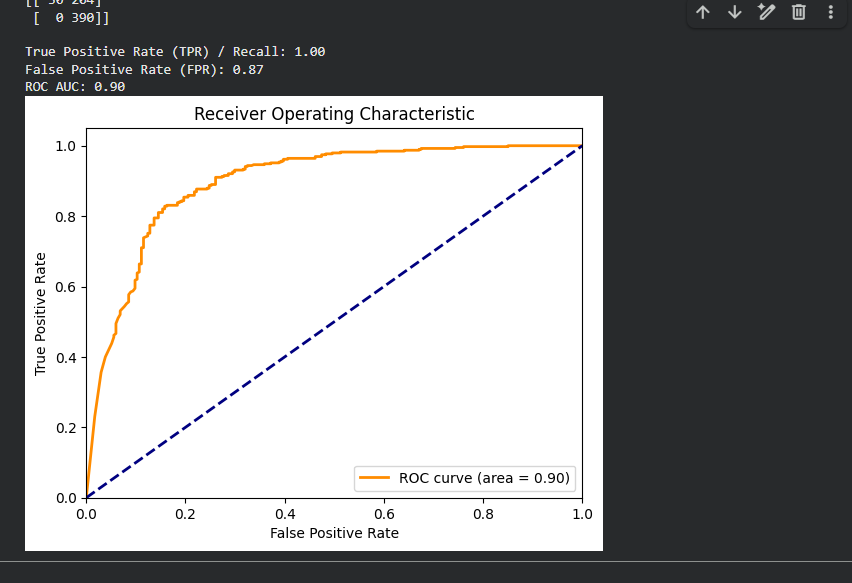

### Investigations Conclusion
Overall, these investgation demonstrate that using raw image data performs better than using numerical data in some aspects, even when the data used is unbalanced and small. My accuracy without any hyperparameters is 80%, and ROC AUC findings demonstrate that utilizing X-ray models enables the models to extract more relevant features. My validation accuracy was 100%, but this is likely due to overfitting, which makes sense with my high FPR.  All those results indicate that using raw image models will outperform numerical dataset models, but with the terrible TPR AND FPR, they are still vulnerable to data quality issues. More work will need to be implemented in the model to be used in a clinical setting.

## Section 2: Time
Analyse my colleague's claim about saving staff time using raw x-ray image data.

The colleague's claim that they can "save on staff time" is well supported by evidence. Accurately measuring any part of the human body takes a tremendous amount of time, as demonstrated by the radiologist consensus (Cowan, MacDonald and Floyd, 2013), which involved radiologists recording "time on an off-PACS workstation: CT colonography, cardiac CT (coronary arteries, pulmonary vein mapping, congenital cardiac anomalies)," with the gathered times fixed at 25, 60, 40, and 40 minutes, respectively. Although this study focuses on CT scans, they do relate to X-ray images in terms of the broader aspect of extracting measurements manually, which takes up a lot of staff time. Measuring just one X-ray requires a significant amount of time, and additionally, the radiologist may need to upload that data to the AI model for diagnosis verification or use it to train the AI, which also consumes time. If they have to do that for every X-ray that day, it will be time-consuming and tiring, which could lead to errors. Supported by evidence from (Brady, 2016), there is an "estimated day-to-day rate of 3-5% of studies reported" due to "errors and discrepancies." However, various other factors can also contribute to this issue, such as staff inexperience. Regardless, errors in measurement could lead to significant problems, especially if the data is later used to train the AI model, which may result in inaccurate predictions of diagnoses or incorrect results being sent back after the AI checks the diagnoses. Overall, the manual measurement of x-rays is extremely slow and prone to errors.

In contrast, by classifying the raw x-ray image data directly into AI models like CNN, the models are able to "detect spatial hierarchies in images… while preserving critical features and fully connected layers that synthesize these features into predictions," according to (Ibomoiye Domor Mienye et al., 2025). Models "have generally enhanced the speed and accuracy… compared to the traditional approach of interpreting medical images by experienced radiologists," stated by (Itunuoluwa Isewon, Alagbe and Jelili Oyelade, 2025). The result helps prove the colleague's claim that automation will decrease the workload, since it will extract measurements and patterns from the images a lot faster and a lot more accurately compared to radiologists's manual measurements.

###Investigations: Time to for model to learn
Seeing how long it takes for the CNN model to learn

Based on the information I obtained from (Cowan, MacDonald and Floyd, 2013), I anticipate that the process of fully measuring chest X-rays and recording the measurements should take a minimum of 25 minutes.  The numerical dataset I've been using has 581 X-ray measurements. So multiplying 581 by 25 minutes, I get an estimated result of 468 hours and 52 minutes to collect and store that data.

The process of taking X-ray images takes slightly less than 30 seconds. It might take a minute or 2 to upload them, but even then the time taken to collect the data will be around a maximum of 2 minutes and 30 seconds. Multiplying that by the 581 X-ray measurements, I get a result of approximately 24 hours and 12.5 minutes, which is a lot less time taken compared to collecting numerical data.



Training the models using the numerical dataset was almost instant. Training models using image data takes a long time at 64; the time it takes is an average time of 4078.5 seconds, which is around 1.13 hours, which is a long time.

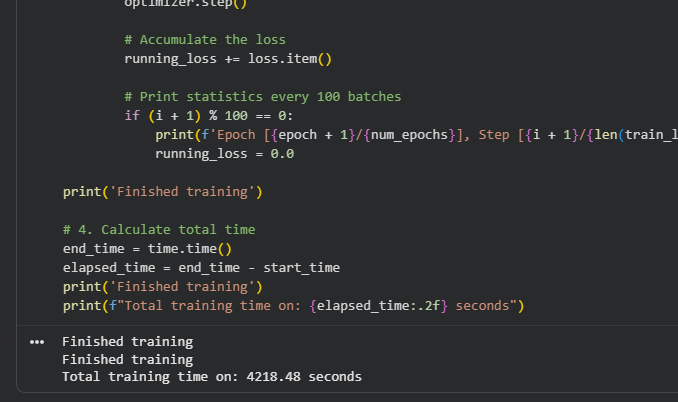
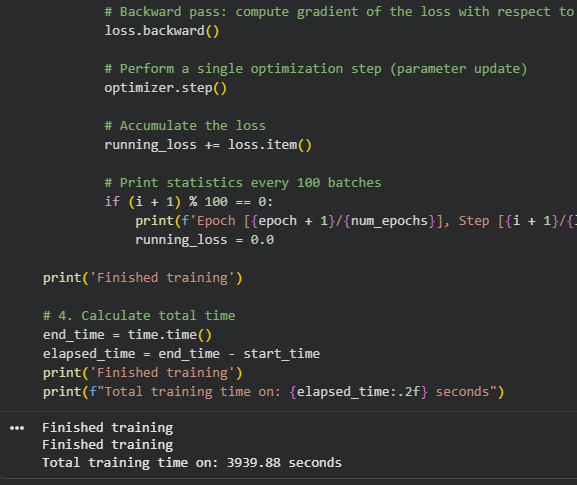

###Investigations Conclusion
Using raw photos still saves a lot of staff time when it comes to data collection, even with lengthy training periods. The x-rays can be supplied immediately and swiftly over the internet rather than having to wait for a radiologist to manually measure each chest x-ray before transmitting that information to us. Indeed, it takes a lot of time to train a model using visual data, but it pales in comparison to the amount of time employees must wait to receive a trustworthy numerical dataset.

## Section 3: ...
Analyse my colleague's claim about there being no downsides time using raw x-ray image data.


My colleague's claims about using raw image data directly has doesn't have any downsides is inaccurate; there are a several important downsides. One being that to train deep learning models, they are heavily dependent on "large-scale, high-quality labeled datasets, which are costly and time-consuming to obtain due to the need for expert annotation” (Yu et al., 2021, as cited in Label-Efficient Deep Learning in Medical Image Analysis: Challenges and Future Directions, 2025). Models are likely to perform poorly or not at all without these datasets. Overfitting and poor generalization are two examples of what could happen to model. Models like CNNs can perform exceptionally well on smaller datasets, but when they are tested on new data, they often fail completely due to poor generalization and overfitting, leading to unsatisfactory outcomes. Hence, why smaller datasets are known as "a source of brittleness," according to (Varoquaux and Cheplygina, 2022). Significant datasets are therefore essential; according to (Varoquaux and Cheplygina, 2022), "overfitting is less of an issue with 'large enough' test data (at least several thousand)." We could build our own dataset, but it would take years to collect enough data to utilize it in a model. A major drawback is that, as my sources indicate, it's quite challenging to locate trustworthy datasets that we can use; this statement directly contradicts the claims made by my colleague.

Another issue with using raw image data is that it does not allow you to see how models arrive at their decisions; like (Li et al., 2023) describes "deep learning models are sometimes referred to as 'black boxes' because they can be tricky to read, making it difficult to comprehend how they made judgments." As a result, in this case, it's difficult to confirm whether the models have utilized the correct measurements of the pattern to determine a result. It's very possible for AI models, such as CNN, to miss these measurements due to focusing on irrelevant patterns during training or just ignoring measurements because they seem insignificant. And because of that issue, it's difficult to validate whether or not it's appropriate for a medical use. As (NHS England, 2019) states, "procurement or commissioning entities may decide that the available evidence for an AI technology does not provide sufficient confidence that its performance will be acceptable in the local situation." Medical organizations won't employ the model if they don't understand how it works, even if it performs incredibly well in practice. If they are unable to confirm if it will predict accurately and not endanger patients, they will find it unacceptable to use in a medical setting. These examples verify that my colleague's claims are indeed inaccurate about there being no drawbacks; even if a model was performing exceptionally well, the lack of visibility of how a model works will prevent the model's use, which is a very significant downside.







###Investigations: Training with different data percentages

For each data percentage (10%, 30%, and 100%) and seeing how the test accuracy changes. I split the number of samples I want to use matched with each percentage.

In [ ]:
import torch
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np


train_batch_size = 128 # Increased batch size to 128 from 64 (has not made a difference though when tested at 64)

train_subset = encoded_dataset['train']

# Get the labels for the current train_subset
train_subset_labels = [item['labels'] for item in train_subset]

# Get indices for 10% of the train_subset
train_10_indices, _ = train_test_split(
    np.arange(len(train_subset)),
    test_size=0.9, # Taking 10%
    random_state=42,
    stratify=train_subset_labels # Stratify based on labels within this subset
)
train_subset_10 = Subset(train_subset, train_10_indices)
train_loader_10 = DataLoader(
    train_subset_10,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
#Checking if 10% has been taken
print(f"Number of samples in train_loader_10: {len(train_subset_10)}")


# Get indices for 30% of the train_subset
train_30_indices, _ = train_test_split(
    np.arange(len(train_subset)), # Use indices for splitting
    test_size=0.7, # Taking 30%
    random_state=42,
    stratify=train_subset_labels
)
train_subset_30 = Subset(train_subset, train_30_indices)
train_loader_30 = DataLoader(
    train_subset_30,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
#Checking if 30% has been taken
print(f"Number of samples in train_loader_30: {len(train_subset_30)}")


# train_loader_100
train_loader_100 = DataLoader(
    train_subset, # 100% of the dataset
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
train_subset_100 = train_subset
#Checking if 100% has been taken
print(f"Number of samples in train_loader_100: {len(train_subset_100)}")

The purpose of the function below is to train the model and evaluate the accuracy.

In [ ]:
def train_and_evaluate_model(train_loader, test_loader, num_epochs=5, learning_rate=0.001):#function for evaluating the model
    model = CNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\nStarting training with {len(train_loader.dataset)} samples...")

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        for i, batch in enumerate(train_loader):
            inputs = batch['inputs']
            labels = batch['labels']

            optimizer.zero_grad()
            outputs = model(inputs)
            labels = labels.long()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()


    # Evaluate the model on the test set
    model.eval() # Set model to evaluation mode
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for batch in test_loader:
            inputs = batch['inputs']
            labels = batch['labels']

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    accuracy = (correct_predictions / total_samples) * 100
    print(f'Final Test Accuracy: {accuracy:.2f}%')#return accuarcy
    return accuracy

Uses function above on split samples then gives accuracy results.

In [ ]:
results = {}
num_epochs_for_experiment = 5

print("\n")
print("Training with 10% of the data...")
results['10%'] = train_and_evaluate_model(train_loader_10, test_loader, num_epochs=num_epochs_for_experiment)#dictonary key
print("\n")

print("\n")
print("Training with 30% of the data...")
results['30%'] = train_and_evaluate_model(train_loader_30, test_loader, num_epochs=num_epochs_for_experiment)
print("\n")

print("\n")
print("Training with 100% of the data...")
results['100%'] = train_and_evaluate_model(train_loader_100, test_loader, num_epochs=num_epochs_for_experiment)
print("\n")

print("Final Results")
for percentage, accuracy in results.items():
    print(f"Accuracy with {percentage} of data: {accuracy:.2f}%")

### Investigations Conclusion

One flaw I discussed earlier with using raw image data is that if the dataset isn't large enough, the model may fail or have poor accuracy. As you can see with the investigation above, the more data available, the higher the accuracy.

# Conclusion
The Gaussian Naive Bayes model is the best model for this task, but it has the same difficulty as the other models, making it somewhat inappropriate for non-medical professionals to employ supervised learning to quickly and accurately diagnose pneumonia based only on these straightforward numerical measures based on this data. Despite displaying excellent initial and K-fold validation accuracy, some models accuracy is deceptive. Additional evaluations of the models, such as ROC AUC, true positive rate (TPR), and false positive rate (FPR), show that the models are genuinely unable to generalize the data. Low TPR values were frequently associated with low FPR, whereas high TPR values were frequently associated with high FPR. The models, which have a ROC AUC of about 0.5, are unable to recognize patterns or distinguish between positive and negative cases. All these factors lead to the fact the dataset is unbalanced, which it is. An overall observation ratio check revealed a ratio of 2.48, with 29% of cases being yes and 71% being no cases. Because of that most models tend favor the majority class but others compensate and over predict the cases that are posistve , this explains why the accuracies are so high yet the TPR, FPR, and ROC AUC findings are so badbased on this data.

However, the Gaussian Naive Bayes model is expected to perform the best among all the models because it was less wrong. Its accuracy on unseen data and TPR/FPR is quite acceptable compared to the other models. Even though its k-fold cross-validation accuracy wasn't as high as the other models paired with the ROC AUC, the model's average k-fold cross-validation accuracy is most likely to be correct, whereas the other models are misleading. If the data is unbalanced, as it was in this case, the model may not perform adequately for diagnosing patients; while it may correctly identify most positive cases, it will also incorrectly classify many healthy patients as positive, leading to a waste of hospital resources and time. Even when multiple ensembles are applied to improve the model, the performance did not improve, primarily due to the imbalance in the dataset. Although the Gaussian Naive Bayes model is currently the best choice, it could be significantly more effective at predicting diagnoses if the dataset were more balanced.

In the investigation, I am in agreement with my colleague's claim mostly. I disagree with the claim that there are no drawbacks, but in terms of performance improvement, the suggested adjustments will increase efficiency and save staff time. Research like that of (Olamilekan Shobayo and Reza Saatchi, 2025) has demonstrated the effectiveness of using raw x-ray pictures with deep learning models, and my own investgations have demonstrated superior accuracy and overall performance when compared to the use of manually extracted data. Furthermore, even though deep learning model training takes a lot of time, it saves a substantial amount of time as compared to manually extracting data and uploading it for model use. My colleague is wrong, though, to say that there are no drawbacks; there are a number of disadvantages to using solely raw image data, the most important of which is the inability to see which features the model utilizes for training. However, there are plenty of solutions that can reduce the severity of all these drawbacks, like using heatmaps to see the features the model had focused on.

In contrast to using numerical data, raw image data is a much better option. My numerical dataset was unbalanced, causing the models to fail to generalize, but if the raw image dataset was also unbalanced, the same result would occur. Although the raw image data has a greater number of benefits compared to entering the data manually. For example, deep learning can extract relevant features that might be overlooked when data is measured manually. In the end, I agree with my colleagues' claim to an extent. I agree it's efficient and will yield a greater performance compared to entering the data manually, but they are wrong to say it has no downsides. There are many downsides; however, they can be managed.

# References
NHS England (2019) 3.2 Evaluation and validation | Workforce, training and education | NHS England, NHS England | Workforce, training and education | Digital Transformation. Available at: https://digital-transformation.hee.nhs.uk/building-a-digital-workforce/dart-ed/horizon-scanning/understanding-healthcare-workers-confidence-in-ai/chapter-3-governance/evaluation-and-validation?st_source=ai_mode (Accessed: 2 January 2026).

Brady, A.P. (2016) ‘Error and discrepancy in radiology: inevitable or avoidable?’, Insights into Imaging, 8(1), pp. 171–182. Available at: https://doi.org/10.1007/s13244-016-0534-1.

Cowan, I.A., MacDonald, S.L. and Floyd, R.A. (2013) ‘Measuring and managing radiologist workload: Measuring radiologist reporting times using data from a Radiology Information System’, Journal of Medical Imaging and Radiation Oncology, 57(5), pp. 558–566. Available at: https://doi.org/10.1111/1754-9485.12092.

Face, H. (2025) chest-xray-pneumonia, Huggingface.co. Available at: https://huggingface.co/datasets/hf-vision/chest-xray-pneumonia.

Ibomoiye Domor Mienye et al. (2025) ‘Deep Convolutional Neural Networks in Medical Image Analysis: A Review’, Information, 16(3), p. 195. Available at: https://doi.org/10.3390/info16030195.

Itunuoluwa Isewon, Alagbe, E. and Jelili Oyelade (2025) ‘Optimizing machine learning performance for medical imaging analyses in low-resource environments: The prospects of CNN-based Feature Extractors’, F1000Research, 14, pp. 100–100. Available at: https://doi.org/10.12688/f1000research.156122.1.

Kumar, R.R. et al. (2025) ‘Advances in Deep Learning for Medical Image Analysis: A Comprehensive Investigation’, Journal of Statistical Theory and Practice, 19(1). Available at: https://doi.org/10.1007/s42519-024-00422-2.

Label-Efficient Deep Learning in Medical Image Analysis: Challenges and Future Directions (2025) Arxiv.org. Available at: https://arxiv.org/html/2303.12484v5#bib.bib343 (Accessed: 6 January 2026).

Li, M. et al. (2023) ‘Medical image analysis using deep learning algorithms’, Frontiers in Public Health, 11(1273253). Available at: https://doi.org/10.3389/fpubh.2023.1273253.

Luna, J.C. (2025) PyTorch CNN Tutorial: Build and Train Convolutional Neural Networks in Python, Datacamp.com. DataCamp. Available at: https://www.datacamp.com/tutorial/pytorch-cnn-tutorial.

Olamilekan Shobayo and Reza Saatchi (2025) ‘Developments in Deep Learning Artificial Neural Network Techniques for Medical Image Analysis and Interpretation’, Diagnostics, 15(9), pp. 1072–1072. Available at: https://doi.org/10.3390/diagnostics15091072.

SpectralAI (2024) Artificial Intelligence in Medical Imaging | AI in Imaging, Spectral AI: UK. Available at: https://www.spectral-ai.com/uk/blog/artificial-intelligence-in-medical-imaging/.

Varoquaux, G. and Cheplygina, V. (2022) ‘Machine learning for medical imaging: methodological failures and recommendations for the future’, npj Digital Medicine, 5(1), pp. 1–8. Available at: https://doi.org/10.1038/s41746-022-00592-y.

Yu, H. et al. (2021) ‘Convolutional neural networks for medical image analysis: State-of-the-art, comparisons, improvement and perspectives’, Neurocomputing, 444, pp. 92–110. Available at: https://doi.org/10.1016/j.neucom.2020.04.157.